# Phase 1 — Dataset Exploration & Preparation

Dataset: blood cell images — 4 classes: **Eosinophil, Lymphocyte, Monocyte, Neutrophil**

This notebook covers everything in Phase 1:
1. Folder structure check
2. Image counts per class
3. Sample images from each class
4. Class balance check
5. Image dimension check
6. Preprocessing (resize + normalize)
7. Building train / val / test generators (80/20 split)
8. Batch shape display
9. Pixel intensity distributions
10. Mean image per class
11. Augmentation preview

All figures are saved to `outputs/figures/`.

In [10]:
import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 10

print('imports ok')

imports ok


In [11]:
# step up to project root if running from notebooks/
if Path.cwd().name == 'notebooks':
    os.chdir('..')

ROOT       = Path('.')
DATA_ROOT  = Path('../Data')
TRAIN_DIR  = DATA_ROOT / 'TRAIN'
TEST_DIR   = DATA_ROOT / 'TEST'
SIMPLE_DIR = DATA_ROOT / 'TEST_SIMPLE'
FIGS       = ROOT / 'outputs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

CLASSES = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
COLORS  = ['#4FA3D1', '#5DBB8A', '#E8A838', '#D15F4F']
IMG_SIZE = (224, 224)   # all images resized to this for training
BATCH_SIZE = 32

for p in [TRAIN_DIR, TEST_DIR, SIMPLE_DIR]:
    print(f"  {'OK' if p.exists() else 'MISSING'}  {p}")

  OK  ..\Data\TRAIN
  OK  ..\Data\TEST
  OK  ..\Data\TEST_SIMPLE


## 1. Folder structure

Check that every class folder exists in every split.

In [12]:
splits = {'TRAIN': TRAIN_DIR, 'TEST': TEST_DIR, 'TEST_SIMPLE': SIMPLE_DIR}

print('Folder structure check:')
for split, split_dir in splits.items():
    print(f'  {split}/')
    for cls in CLASSES:
        cls_dir = split_dir / cls
        status  = 'OK' if cls_dir.exists() else 'MISSING'
        print(f'    [{status}]  {cls}/')

print('\nAll folders present:', all(
    (split_dir / cls).exists()
    for split_dir in splits.values()
    for cls in CLASSES
))

Folder structure check:
  TRAIN/
    [OK]  EOSINOPHIL/
    [OK]  LYMPHOCYTE/
    [OK]  MONOCYTE/
    [OK]  NEUTROPHIL/
  TEST/
    [OK]  EOSINOPHIL/
    [OK]  LYMPHOCYTE/
    [OK]  MONOCYTE/
    [OK]  NEUTROPHIL/
  TEST_SIMPLE/
    [OK]  EOSINOPHIL/
    [OK]  LYMPHOCYTE/
    [OK]  MONOCYTE/
    [OK]  NEUTROPHIL/

All folders present: True


## 2. Image count per class

Count how many images are in each class for TRAIN and TEST.

In [13]:
def count_cls(split_dir):
    return {
        cls: len([f for f in (split_dir / cls).glob('*')
                  if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
        for cls in CLASSES
    }

counts = {s: count_cls(d) for s, d in splits.items()}

# print table
print(f"{'Class':<16}", end='')
for s in splits:
    print(f"{s:>12}", end='')
print()
print('-' * 52)
for cls in CLASSES:
    print(f"{cls:<16}", end='')
    for s in splits:
        print(f"{counts[s][cls]:>12,}", end='')
    print()
print('-' * 52)
print(f"{'TOTAL':<16}", end='')
for s in splits:
    print(f"{sum(counts[s].values()):>12,}", end='')
print()

Class                  TRAIN        TEST TEST_SIMPLE
----------------------------------------------------
EOSINOPHIL             2,497         623          13
LYMPHOCYTE             2,483         620           6
MONOCYTE               2,478         620           4
NEUTROPHIL             2,499         624          48
----------------------------------------------------
TOTAL                  9,957       2,487          71


## 3. Sample images from each class

Let's look at what the cells actually look like.

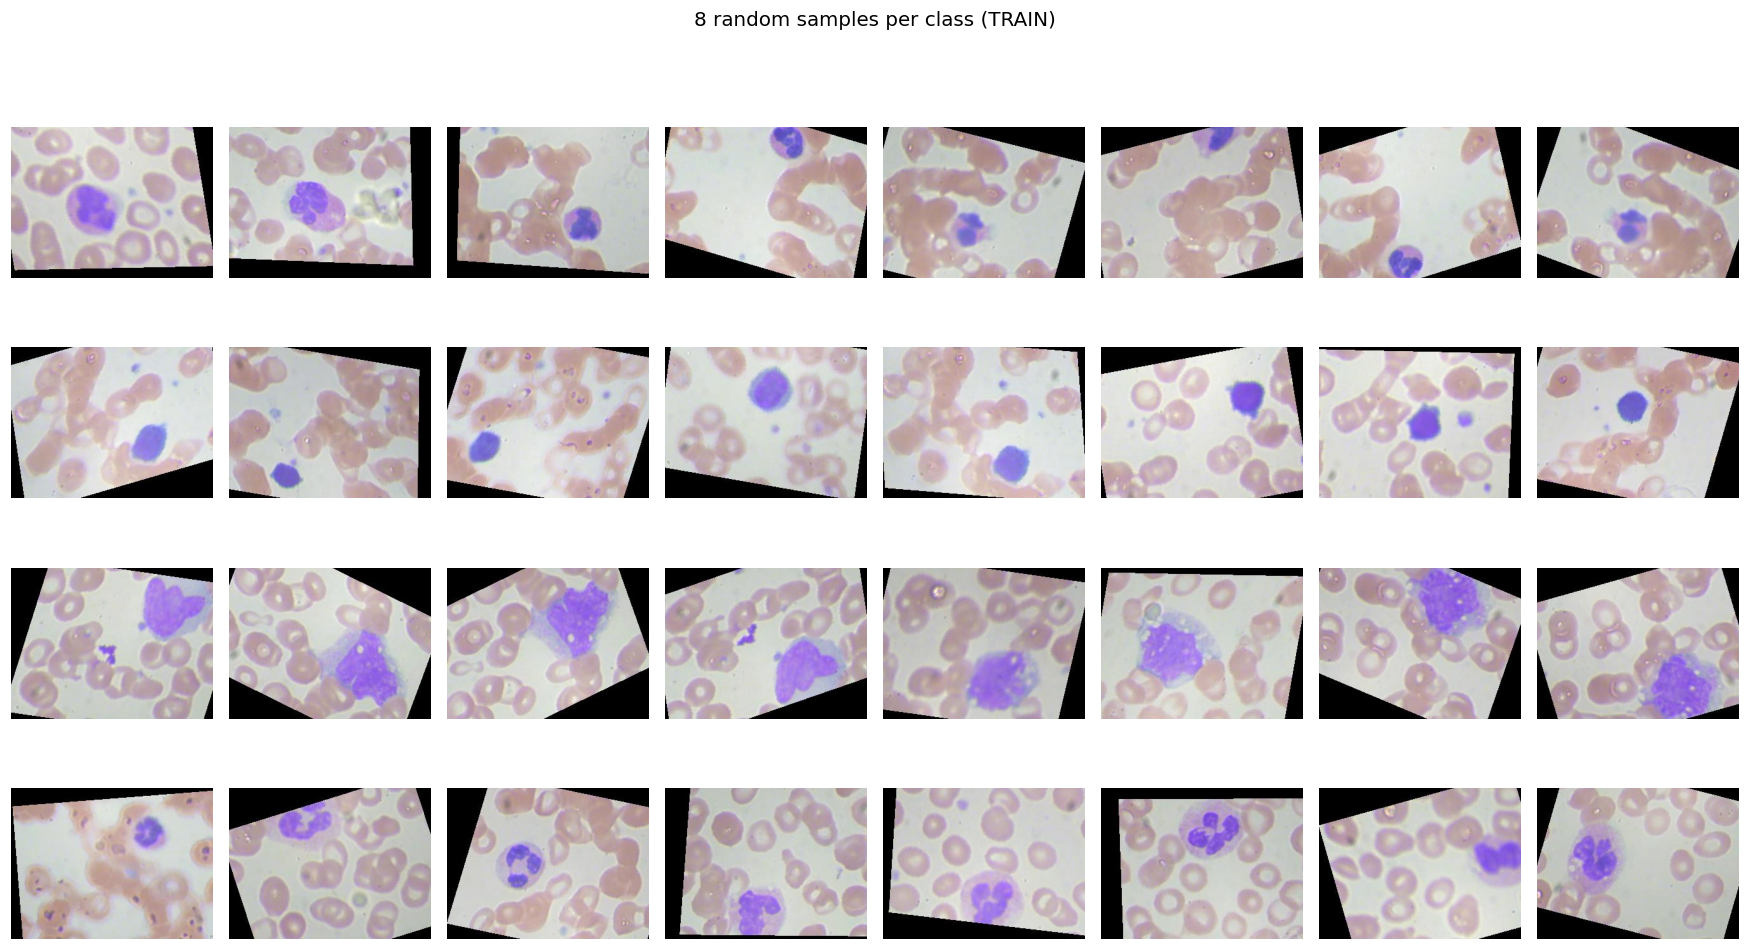

saved -> outputs/figures/eda_01_sample_grid.png

Visual notes:
  Eosinophil  — pink/orange granules, bi-lobed nucleus
  Lymphocyte  — large round dark nucleus, small cytoplasm
  Monocyte    — kidney-shaped nucleus, large cell
  Neutrophil  — multi-lobed purple nucleus, most common WBC
  Hardest pair to separate: Monocyte vs Lymphocyte



In [14]:
fig, axes = plt.subplots(4, 8, figsize=(16, 9))

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    paths  = list((TRAIN_DIR / cls).glob('*.jpeg'))
    chosen = random.sample(paths, 8)
    for col, p in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(np.array(Image.open(p)))
        ax.axis('off')
    axes[row, 0].set_ylabel(cls, fontsize=9, color=color,
                             rotation=0, labelpad=72, va='center')

fig.suptitle('8 random samples per class (TRAIN)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'eda_01_sample_grid.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_01_sample_grid.png')

print("""
Visual notes:
  Eosinophil  — pink/orange granules, bi-lobed nucleus
  Lymphocyte  — large round dark nucleus, small cytoplasm
  Monocyte    — kidney-shaped nucleus, large cell
  Neutrophil  — multi-lobed purple nucleus, most common WBC
  Hardest pair to separate: Monocyte vs Lymphocyte
""")

## 4. Class balance

Are the classes balanced? This matters because imbalanced classes can bias the model towards the majority class.

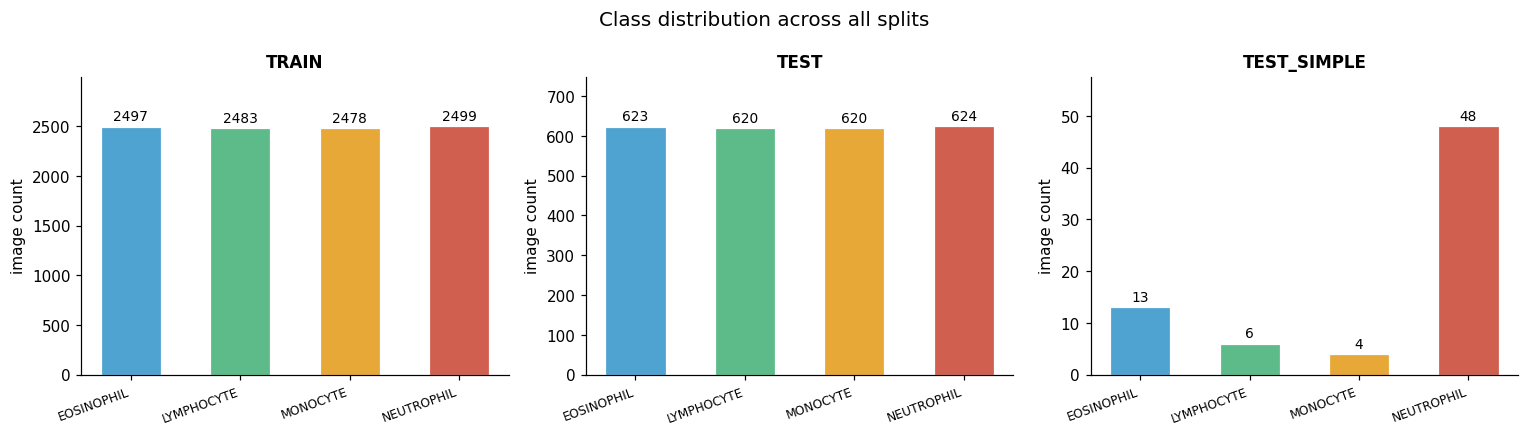

saved -> outputs/figures/eda_02_class_distribution.png
TRAIN: max-min difference = 21 images  (0.8% of mean)  → balanced
TEST: max-min difference = 4 images  (0.6% of mean)  → balanced


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (split, _) in zip(axes, splits.items()):
    vals = [counts[split][cls] for cls in CLASSES]
    bars = ax.bar(CLASSES, vals, color=COLORS, width=0.55,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.012,
                str(v), ha='center', va='bottom', fontsize=9)
    ax.set_title(split, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.20)
    ax.set_xticklabels(CLASSES, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('image count')

fig.suptitle('Class distribution across all splits', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'eda_02_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_02_class_distribution.png')

# balance check
for split in ['TRAIN', 'TEST']:
    vals = list(counts[split].values())
    imbalance = (max(vals) - min(vals)) / np.mean(vals) * 100
    print(f'{split}: max-min difference = {max(vals)-min(vals)} images  '
          f'({imbalance:.1f}% of mean)  → {"balanced" if imbalance < 5 else "imbalanced"}')

## 5. Image dimensions

We need to know the original size before we resize.

In [16]:
all_paths = list(TRAIN_DIR.glob('*/*.jpeg'))
sample    = random.sample(all_paths, min(300, len(all_paths)))
sizes     = [Image.open(p).size for p in sample]

size_counts = Counter(sizes)
widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f'Unique sizes   : {len(size_counts)}')
print(f'Most common    : {size_counts.most_common(1)[0]}')
print(f'Width          : min {min(widths)}, max {max(widths)}, mean {np.mean(widths):.0f}')
print(f'Height         : min {min(heights)}, max {max(heights)}, mean {np.mean(heights):.0f}')
print(f'All same size  : {len(size_counts) == 1}')
print(f'\nOriginal size  : {size_counts.most_common(1)[0][0][0]} x {size_counts.most_common(1)[0][0][1]} px')
print(f'Training size  : {IMG_SIZE[0]} x {IMG_SIZE[1]} px  (resized)')

Unique sizes   : 1
Most common    : ((320, 240), 300)
Width          : min 320, max 320, mean 320
Height         : min 240, max 240, mean 240
All same size  : True

Original size  : 320 x 240 px
Training size  : 224 x 224 px  (resized)


## 6. Preprocessing

Before feeding images into a CNN we need to:
- **Resize** to a fixed size (224×224) — the network expects all inputs to be the same shape
- **Normalize** pixel values from [0, 255] to [0, 1] — keeps gradients stable during training

Let's show what this looks like on a real image.

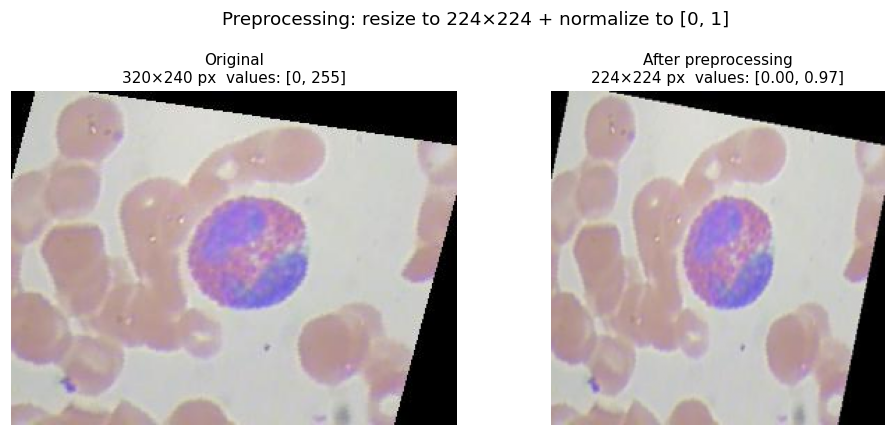

saved -> outputs/figures/eda_06_preprocessing.png

Original array  : shape=(240, 320, 3), dtype=uint8
Processed array : shape=(224, 224, 3), dtype=float64


In [17]:
img_path = list((TRAIN_DIR / 'EOSINOPHIL').glob('*.jpeg'))[0]
original = Image.open(img_path)
resized  = original.resize(IMG_SIZE)
arr_orig = np.array(original)
arr_norm = np.array(resized) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(arr_orig)
axes[0].set_title(
    f'Original\n{arr_orig.shape[1]}×{arr_orig.shape[0]} px  '
    f'values: [{arr_orig.min()}, {arr_orig.max()}]',
    fontsize=10)
axes[0].axis('off')

axes[1].imshow(arr_norm)
axes[1].set_title(
    f'After preprocessing\n{arr_norm.shape[1]}×{arr_norm.shape[0]} px  '
    f'values: [{arr_norm.min():.2f}, {arr_norm.max():.2f}]',
    fontsize=10)
axes[1].axis('off')

fig.suptitle('Preprocessing: resize to 224×224 + normalize to [0, 1]', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'eda_06_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_06_preprocessing.png')

print(f'\nOriginal array  : shape={arr_orig.shape}, dtype={arr_orig.dtype}')
print(f'Processed array : shape={arr_norm.shape}, dtype={arr_norm.dtype}')

## 7. Building generators (80 / 20 train-val split)

We split TRAIN into **80% training** and **20% validation** using Keras `ImageDataGenerator`.

**Why shuffle train but not val/test?**
- `train`: shuffled so each batch has a random mix of all 4 classes. Without shuffle, the model might see all Eosinophils in the first few batches and all Neutrophils in the last — this makes the loss gradient unreliable.
- `val` and `test`: **not** shuffled so we can reproduce the exact same evaluation order every run, and match predictions back to images if needed.

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

VAL_SPLIT = 0.20   # 80/20

# train generator: augmentation + shuffle
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.80, 1.20],
    fill_mode='nearest',
    validation_split=VAL_SPLIT
)

# val / test generator: just rescale, no augmentation
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,        # <-- shuffled
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,       # <-- not shuffled
    seed=42
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False        # <-- not shuffled
)

print(f'\nClass index mapping : {train_gen.class_indices}')
print(f'\nTrain   : {train_gen.samples:,} images  ({train_gen.samples/sum(counts["TRAIN"].values())*100:.0f}%)')
print(f'Val     : {val_gen.samples:,} images  ({val_gen.samples/sum(counts["TRAIN"].values())*100:.0f}%)')
print(f'Test    : {test_gen.samples:,} images')
print(f'\nTrain batches : {len(train_gen)}')
print(f'Val batches   : {len(val_gen)}')
print(f'Test batches  : {len(test_gen)}')

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.

Class index mapping : {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}

Train   : 7,968 images  (80%)
Val     : 1,989 images  (20%)
Test    : 2,487 images

Train batches : 249
Val batches   : 63
Test batches  : 78


## 8. Batch shape

Let's pull one batch from the training generator and check the shapes.

One training batch:
  batch_X shape : (32, 224, 224, 3)  →  (batch, height, width, channels)
  batch_y shape : (32, 4)  →  (batch, num_classes)  [one-hot]
  pixel range   : [0.000, 1.000]
  dtype         : float32


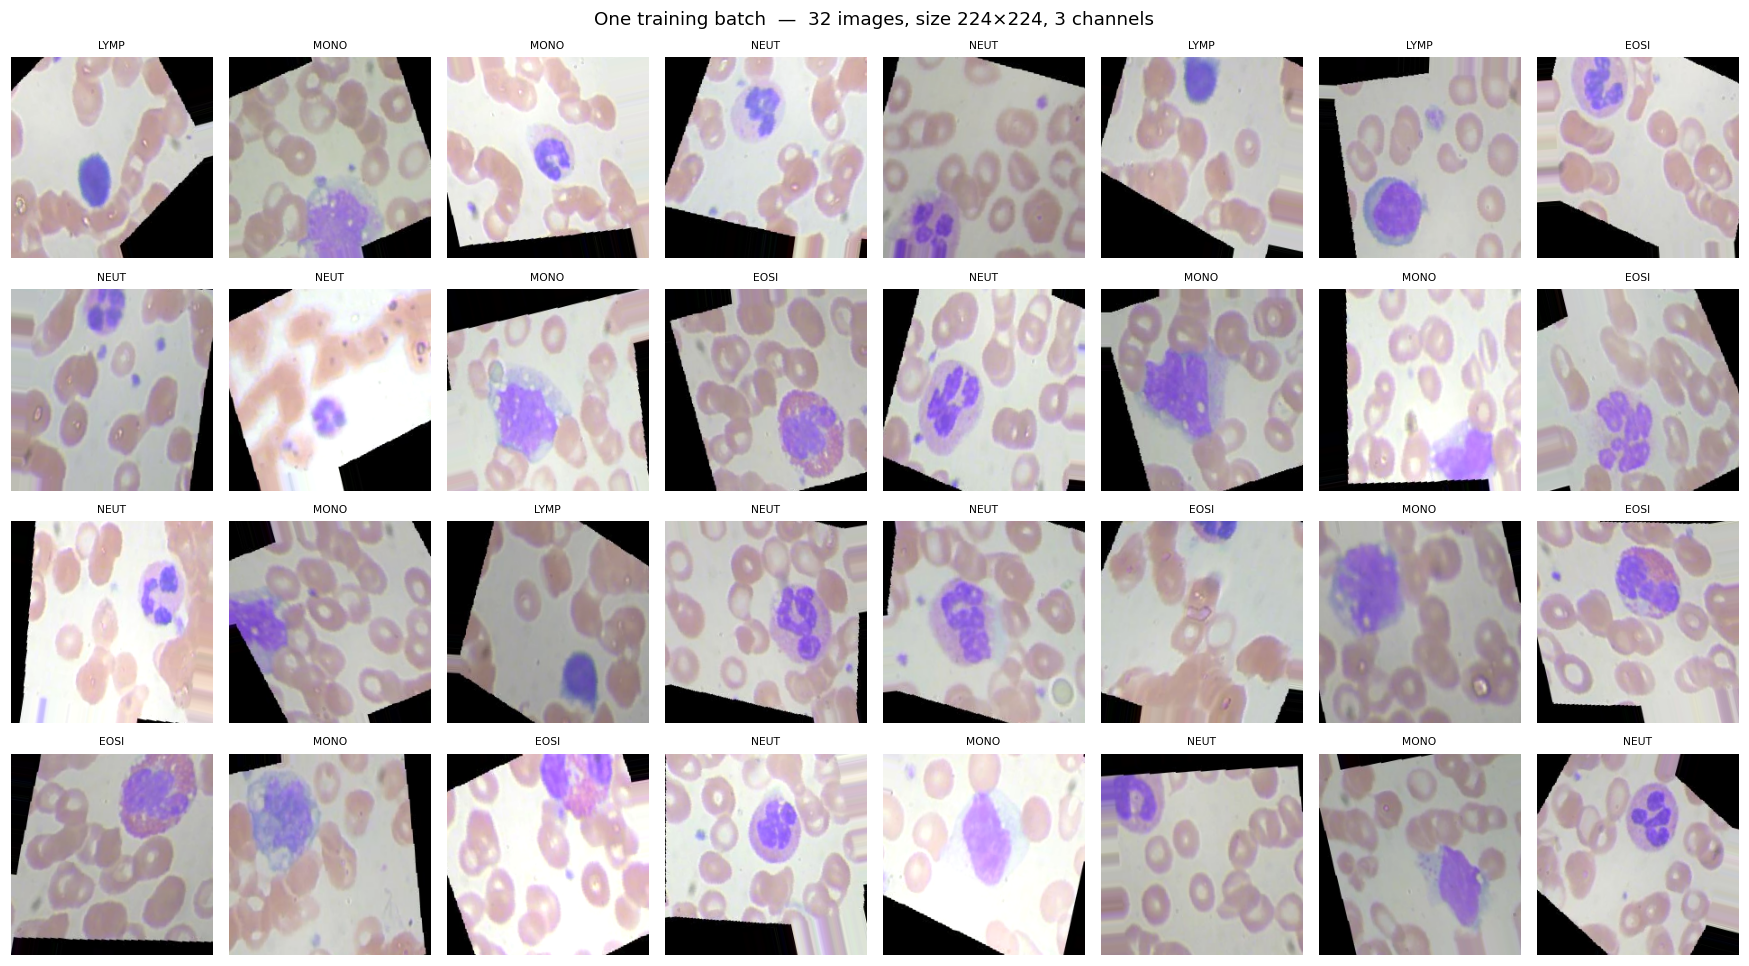

saved -> outputs/figures/eda_07_batch_display.png


In [19]:
batch_X, batch_y = next(train_gen)

print('One training batch:')
print(f'  batch_X shape : {batch_X.shape}  →  (batch, height, width, channels)')
print(f'  batch_y shape : {batch_y.shape}  →  (batch, num_classes)  [one-hot]')
print(f'  pixel range   : [{batch_X.min():.3f}, {batch_X.max():.3f}]')
print(f'  dtype         : {batch_X.dtype}')

# show the 32 images in the batch
fig, axes = plt.subplots(4, 8, figsize=(16, 9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_X[i])
    ax.set_title(CLASSES[batch_y[i].argmax()][:4], fontsize=7)
    ax.axis('off')

fig.suptitle(f'One training batch  —  {BATCH_SIZE} images, size {IMG_SIZE[0]}×{IMG_SIZE[1]}, 3 channels', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'eda_07_batch_display.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_07_batch_display.png')

## 9. Pixel intensity per class

Different cell types stain differently. Let's check how the RGB channel distributions compare.

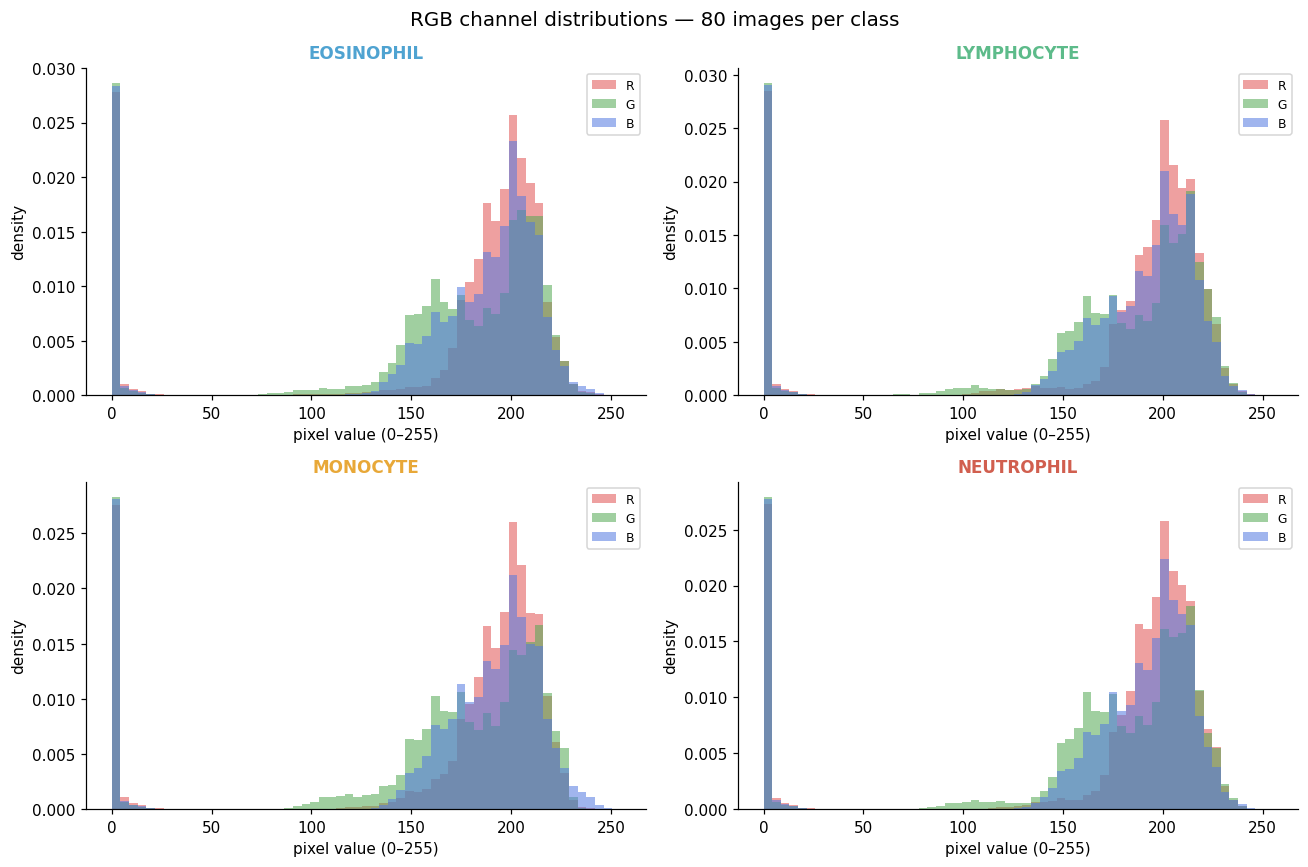

saved -> outputs/figures/eda_03_pixel_histograms.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (cls, color) in zip(axes, zip(CLASSES, COLORS)):
    paths = random.sample(list((TRAIN_DIR / cls).glob('*.jpeg')), 80)
    r_all, g_all, b_all = [], [], []
    for p in paths:
        arr = np.array(Image.open(p))
        r_all.append(arr[:, :, 0].ravel())
        g_all.append(arr[:, :, 1].ravel())
        b_all.append(arr[:, :, 2].ravel())

    bins = np.linspace(0, 255, 60)
    ax.hist(np.concatenate(r_all), bins=bins, color='#E05252',
            alpha=0.55, density=True, label='R')
    ax.hist(np.concatenate(g_all), bins=bins, color='#52A852',
            alpha=0.55, density=True, label='G')
    ax.hist(np.concatenate(b_all), bins=bins, color='#5278E0',
            alpha=0.55, density=True, label='B')
    ax.set_title(cls, fontsize=11, color=color, fontweight='bold')
    ax.set_xlabel('pixel value (0–255)')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

fig.suptitle('RGB channel distributions — 80 images per class', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'eda_03_pixel_histograms.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_03_pixel_histograms.png')

## 10. Mean image per class

Average 100 images per class — gives a rough idea of the typical cell shape and colour for each type.

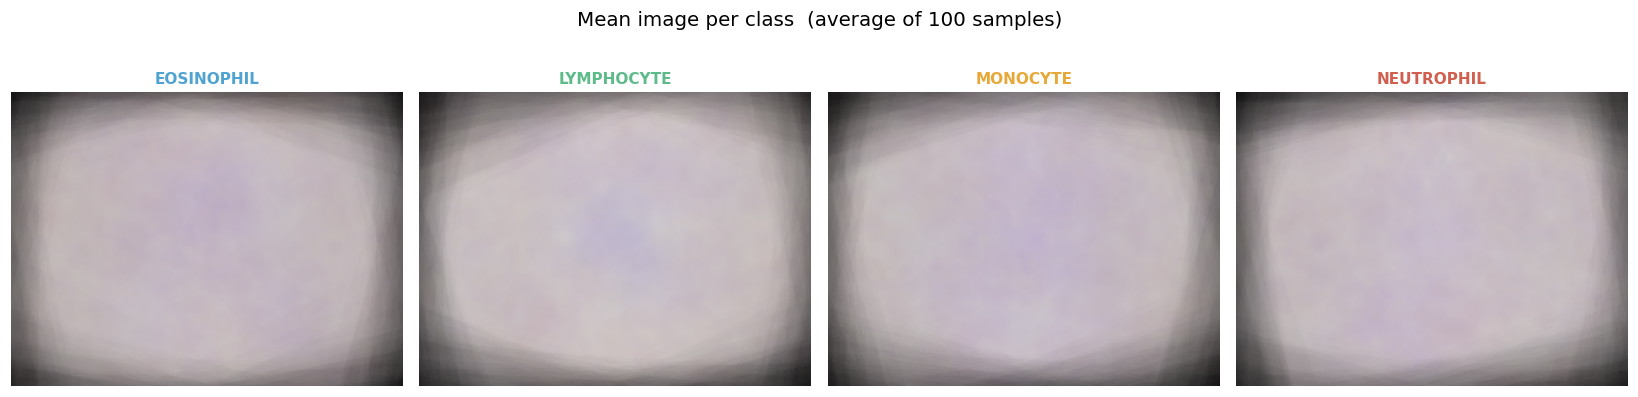

saved -> outputs/figures/eda_04_mean_images.png


In [21]:
TARGET = (320, 240)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (cls, color) in zip(axes, zip(CLASSES, COLORS)):
    paths = random.sample(list((TRAIN_DIR / cls).glob('*.jpeg')), 100)
    stack = np.stack(
        [np.array(Image.open(p).resize(TARGET)) for p in paths]
    )
    mean_img = stack.mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

fig.suptitle('Mean image per class  (average of 100 samples)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'eda_04_mean_images.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_04_mean_images.png')

## 11. Augmentation preview

We apply these transforms to training images only (never val/test):
rotation ±15°, horizontal + vertical flip, zoom ±10%, shift ±10%, brightness ±20%.

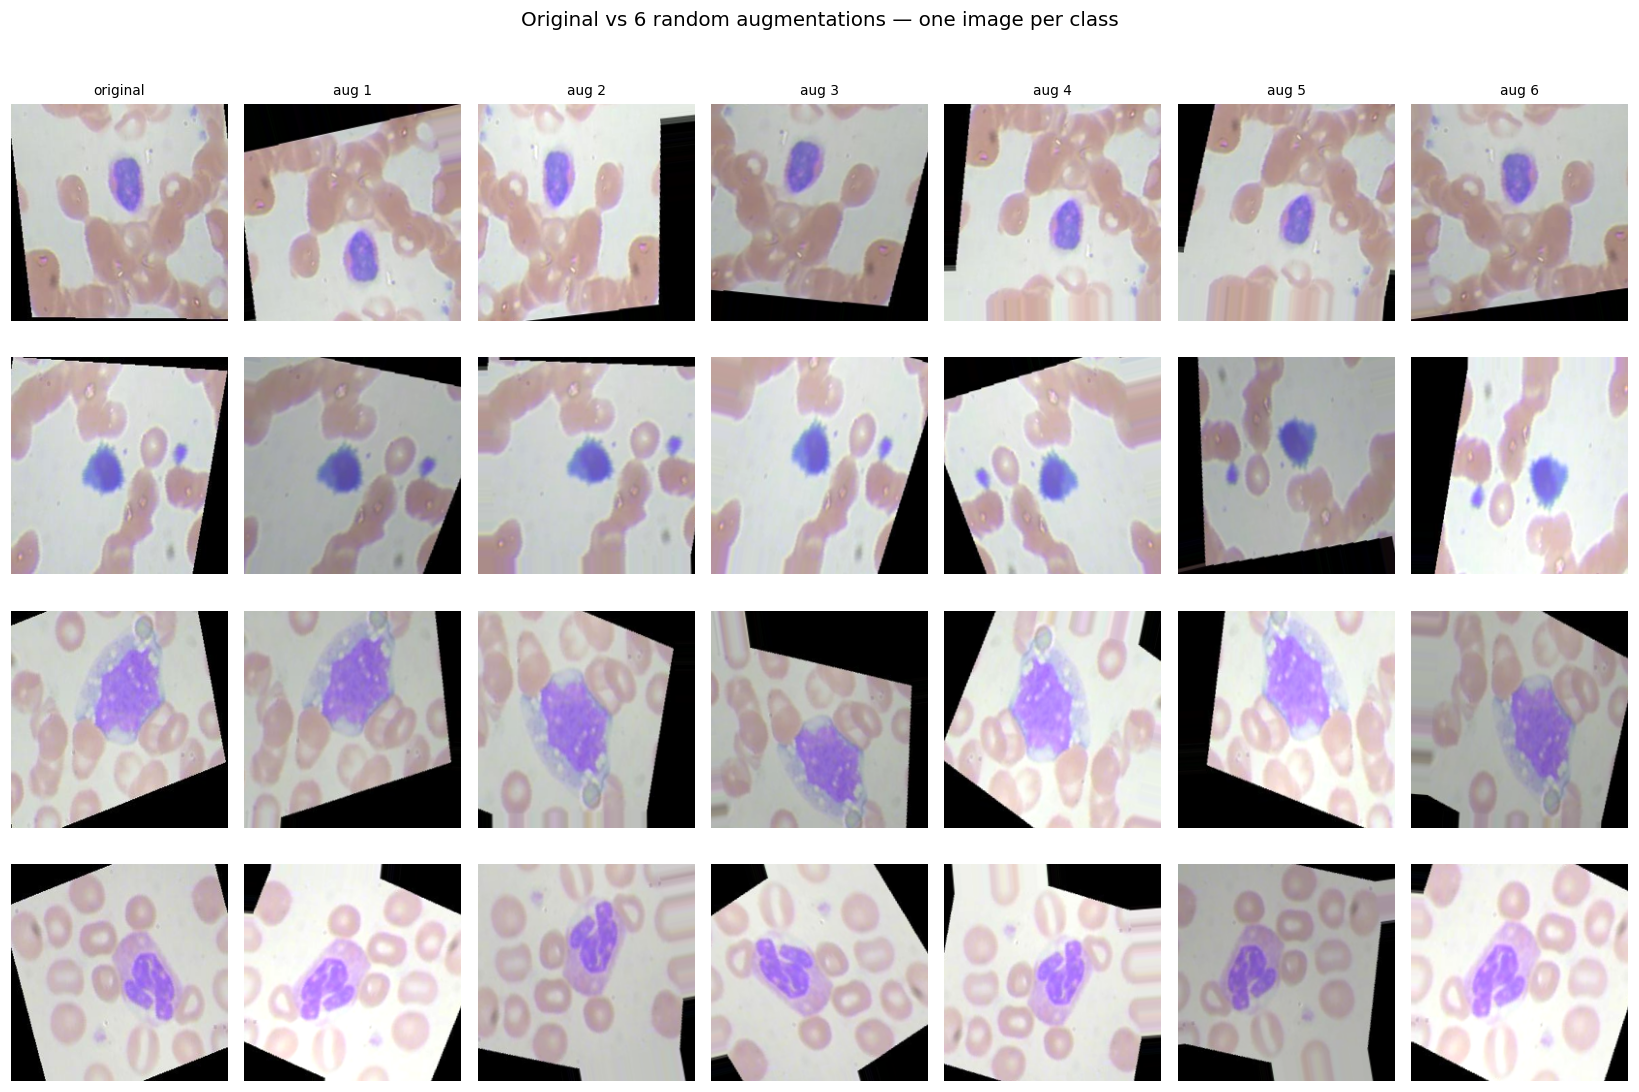

saved -> outputs/figures/eda_05_augmentation_preview.png


In [22]:
aug_preview = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.80, 1.20],
    fill_mode='nearest'
)

fig, axes = plt.subplots(4, 7, figsize=(15, 10))
col_titles = ['original', 'aug 1', 'aug 2', 'aug 3', 'aug 4', 'aug 5', 'aug 6']

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_path = random.choice(list((TRAIN_DIR / cls).glob('*.jpeg')))
    img = np.array(Image.open(img_path).resize(IMG_SIZE))

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(cls, fontsize=9, color=color,
                             rotation=0, labelpad=72, va='center')

    gen = aug_preview.flow(img[np.newaxis], batch_size=1)
    for col in range(1, 7):
        aug_img = next(gen)[0].clip(0, 255).astype(np.uint8)
        axes[row, col].imshow(aug_img)
        axes[row, col].axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9)

fig.suptitle('Original vs 6 random augmentations — one image per class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'eda_05_augmentation_preview.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/eda_05_augmentation_preview.png')

## Summary

| | |
|---|---|
| **Classes** | EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL |
| **Total images** | 9,958 train / 2,488 test / 72 TEST_SIMPLE |
| **Class balance** | All 4 classes nearly equal (<1% difference) — no weighting needed |
| **Original size** | 320×240 px, RGB JPEG |
| **Training size** | Resized to 224×224 px, normalized to [0, 1] |
| **Train/val split** | 80% train (~7,966 images) / 20% val (~1,992 images) |
| **Generators** | train: shuffled + augmented · val: no aug, no shuffle · test: no aug, no shuffle |
| **Batch shape** | (32, 224, 224, 3) images + (32, 4) one-hot labels |

Dataset is clean, balanced, and ready. Moving on to Phase 2 — custom CNN.